Membaca file Excel... Mohon tunggu.
Berhasil membaca 48406 baris data.

TOP 10 ITEM PALING LAKU
Kode  Quantity
K107     32171
A247     26484
M300     17547
K100     16072
A402     15016
A243     12696
A280     12226
A251     11709
K123      9527
K400      8233


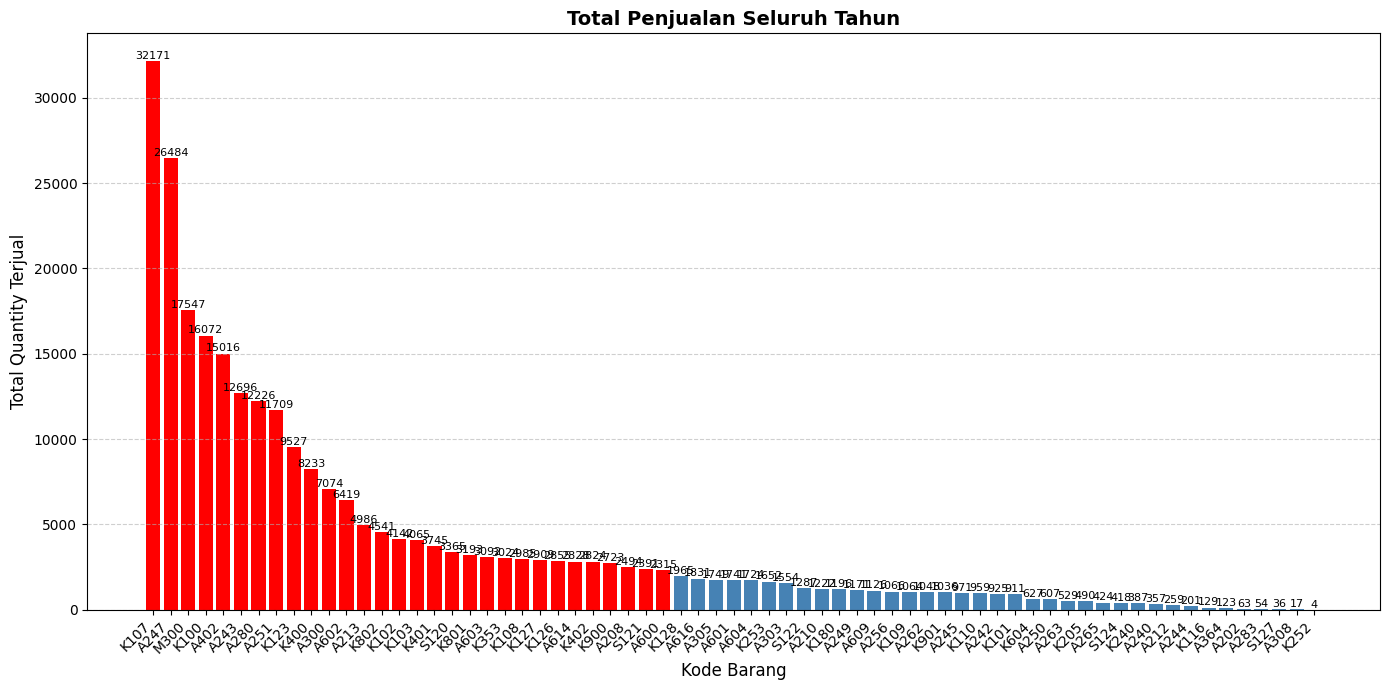

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# from google.colab import drive

# 1. Mount Google Drive
# drive.mount('/content/drive')

# 2. Konfigurasi File & Kolom
file_path = 'data_penjualan_aim_harian_all_products.xlsx'
col_kode = 'Kode'       # Nama Kolom Kode Barang
col_qty = 'Quantity'    # Nama Kolom Jumlah

try:
    # 3. Baca Data
    print("Membaca file Excel... Mohon tunggu.")
    df = pd.read_excel(file_path)
    print(f"Berhasil membaca {len(df)} baris data.")

    # 4. Proses Grouping (Total Penjualan Seluruh Tahun)
    summary_df = df.groupby(col_kode)[col_qty].sum().reset_index()

    # 5. Sorting (Urutkan dari Penjualan Terbanyak)
    summary_df = summary_df.sort_values(by=col_qty, ascending=False)

    # Tampilkan Data di Console (Top 10)
    print("\n" + "="*40)
    print("TOP 10 ITEM PALING LAKU")
    print("="*40)
    print(summary_df.head(10).to_string(index=False))

    # ========================================================
    # 6. MEMBUAT PLOT DIAGRAM BATANG
    # ========================================================

    # PENTING: Agar grafik terbaca, kita ambil Top 30 barang saja.
    # Jika item Anda ada ratusan, grafik akan sangat padat dan sulit dibaca jika di-plot semua.
    # jumlah_item_ditampilkan =  30
    # data_plot = summary_df.head(jumlah_item_ditampilkan)
    jumlah_item_ditampilkan =  30
    data_plot = summary_df

    # Atur Ukuran Gambar (Lebar=14, Tinggi=7)
    plt.figure(figsize=(14, 7))

    # Plot Sumbu X (Kode) dan Y (Quantity)
    # .astype(str) memastikan kode dianggap teks (bukan angka urut)
    warna_bar = ['red' if i < 30 else 'steelblue' for i in range(len(data_plot))]
    bars = plt.bar(data_plot[col_kode].astype(str), data_plot[col_qty], color=warna_bar)

    # Memberi Judul dan Label
    plt.title(f'Total Penjualan Seluruh Tahun', fontsize=14, fontweight='bold')
    plt.xlabel('Kode Barang', fontsize=12)
    plt.ylabel('Total Quantity Terjual', fontsize=12)

    # Memiringkan tulisan di sumbu X agar tidak bertumpuk
    plt.xticks(rotation=45, ha='right')

    # Menambahkan Garis Bantu (Grid) Tipis
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # (Opsional) Menambahkan Angka Persis di Atas Batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval),
                 ha='center', va='bottom', fontsize=8)

    # Tampilkan Grafik
    plt.tight_layout() # Agar layout rapi tidak terpotong
    plt.show()

except Exception as e:
    print(f"\n[ERROR] Terjadi kesalahan: {e}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

# ==========================================
# KONFIGURASI AWAL
# ==========================================
# Abaikan warning agar output bersih
warnings.filterwarnings("ignore")

# Path File Input
file_path = 'data_penjualan_aim_harian_all_products.xlsx'
# Folder Output (Dibuat otomatis jika belum ada)
# if not os.path.exists(output_folder):
#     os.makedirs(output_folder)
#     print(f"Folder output dibuat: {output_folder}")
# else:
#     print(f"Menyimpan hasil di folder: {output_folder}")

# ==========================================
# 1. LOAD & PREPROCESS DATA
# ==========================================
print("\nSedang memuat data Excel... (Mohon tunggu sebentar)")
df = pd.read_excel(file_path)

# Pastikan kolom tanggal bertipe datetime (Format Mixed + Dayfirst)
df["Tanggal"] = pd.to_datetime(df["Tanggal"], dayfirst=True, format='mixed', errors='coerce')
df = df.dropna(subset=["Tanggal"]) # Hapus jika ada tanggal error

# --- DEFINISI PALET WARNA & LABEL BULAN ---
color_map = {
    1: 'red', 2: 'gold', 3: 'green', 4: 'blue', 5: 'purple', 6: 'cyan',
    7: 'magenta', 8: 'orange', 9: 'brown', 10: 'pink', 11: 'teal', 12: 'lime'
}

month_labels = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
    7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'
}

# ==============================================================================
# [BARU] LOGIKA FILTER TOP 30 BARANG TERLARIS
# ==============================================================================
print("\nSedang menghitung Top 30 Barang Terlaris...")

# 1. Kelompokkan per Kode, jumlahkan Quantity, urutkan descending (besar ke kecil)
top_sales = df.groupby('Kode')['Quantity'].sum().sort_values(ascending=False)

# 2. Ambil 30 kode teratas
top_30_codes = top_sales.index.tolist()

# 3. Masukkan ke dalam variabel list_kode_barang yang dipakai looping
list_kode_barang = top_30_codes

print(f"Selesai. Hanya memproses {len(list_kode_barang)} barang teratas.")
print(f"Sampel Barang: {list_kode_barang[:5]} ...")
# ==============================================================================


# Parameter Split Data
test_size = 12  # 12 Bulan terakhir sebagai testing

# Counter untuk laporan akhir
success_count = 0
skip_count = 0

# ==========================================
# 2. LOOPING SETIAP BARANG
# ==========================================
print("\n" + "="*40)
print("MULAI PROSES GENERATE GAMBAR")
print("="*40)

for i, kode_filter in enumerate(list_kode_barang):
    print(f"[{i+1}/{len(list_kode_barang)}] Memproses Kode: {kode_filter} ...", end=" ")

    try:
        # --- A. Filter & Agregasi Bulanan ---
        df_filtered = df[df["Kode"] == kode_filter]

        # Group by Month (Sum Quantity)
        df_monthly = df_filtered.groupby(
            pd.Grouper(key="Tanggal", freq="MS")
        )["Quantity"].sum()

        # 2. [BARU] ISI BULAN KOSONG DENGAN 0
        # Langkah ini memastikan urutan bulan lengkap dari awal sampai akhir data barang tersebut
        df_monthly = df_monthly.resample('MS').asfreq().fillna(0)

        # --- B. Validasi Panjang Data ---
        # Minimal butuh 24 bulan (misal: 12 train + 12 test)
        # if len(df_monthly) < 24:
        #     print(f"-> SKIPPED (Data hanya {len(df_monthly)} bulan)")
        #     skip_count += 1
        #     continue

        # ==========================================
        # 3. GAMBAR 1: SEASONAL PLOT (WARNA + ANGKA)
        # ==========================================
        plt.figure(figsize=(14, 7)) # Ukuran lebar agar angka muat

        # a. Garis Penghubung (Abu-abu tipis)
        plt.plot(df_monthly.index, df_monthly.values, color='lightgray', linestyle='-', linewidth=1.5, zorder=1)

        # b. Titik Warna-warni (Loop per bulan agar legend rapi)
        for m in range(1, 13):
            mask_month = df_monthly.index.month == m
            if mask_month.any():
                plt.scatter(
                    df_monthly[mask_month].index,
                    df_monthly[mask_month].values,
                    color=color_map[m],
                    label=month_labels[m],
                    s=80,               # Ukuran titik
                    edgecolors='black', # Pinggiran hitam
                    linewidth=0.5,
                    zorder=2
                )

        # c. Anotasi Angka Persis
        for date_idx, quantity_val in df_monthly.items():
            label_text = f"{quantity_val:.0f}"
            plt.annotate(
                label_text,
                (date_idx, quantity_val),
                xytext=(0, 8),                  # Geser 8 pixel ke atas
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none") # Kotak background
            )

        plt.title(f"Distribusi Penjualan Bulanan (Color Coded) - {kode_filter}", fontsize=14)
        plt.xlabel("Bulan")
        plt.ylabel("Quantity")
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.legend(title="Bulan", bbox_to_anchor=(1.01, 1), loc='upper left') # Legend di luar
        plt.tight_layout()

        # Simpan Gambar 1
        output_folder_1 = r'E:\UKP\Semester 8\Skripsi\Python\EDA\coba\hasil plot\seasonal-color'
        plt.savefig(os.path.join(output_folder_1, f"{kode_filter}_1_Seasonal_Color.png"))
        plt.close() # Wajib close untuk hemat memori

        # ==========================================
        # 4. GAMBAR 2: TIME SERIES TRAINING DATA
        # ==========================================
        # Split Data
        df_analysis = df_monthly.iloc[:-test_size]

        plt.figure(figsize=(10, 5))
        plt.plot(df_analysis.index, df_analysis.values, marker='o', linestyle='-', color='blue', label='Data Training')
        plt.title(f"Data Training (Time vs Quantity) - {kode_filter}", fontsize=12)
        plt.xlabel("Waktu")
        plt.ylabel("Quantity")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()

        # Simpan Gambar 2
        output_folder_2 = r'E:\UKP\Semester 8\Skripsi\Python\EDA\coba\hasil plot\training-plot'
        plt.savefig(os.path.join(output_folder_2, f"{kode_filter}_2_Training_Plot.png"))
        plt.close()

        # ==========================================
        # 5. GAMBAR 3: ACF & PACF (STATIONARITY CHECK)
        # ==========================================
        # Cek data konstan (variance = 0)
        if df_analysis.nunique() <= 1:
             print("-> SKIPPED ADF (Data konstan)")
             # Tetap dihitung sukses karena gambar seasonal sudah jadi
             success_count += 1
             continue

        # Uji ADF
        adf_result = adfuller(df_analysis)
        p_value = adf_result[1]

        # Logika Differencing
        if p_value > 0.05:
            # Tidak Stasioner -> Lakukan Differencing
            df_plot = df_analysis.diff().dropna()
            status_plot = f"Differenced (d=1) | p-val awal: {p_value:.3f}"
            print(f"-> Done (Non-Stasioner p={p_value:.2f}, Diff d=1)")
        else:
            # Sudah Stasioner
            df_plot = df_analysis
            status_plot = f"Original (d=0) | p-val: {p_value:.3f}"
            print(f"-> Done (Stasioner p={p_value:.2f})")

        plt.figure(figsize=(12, 5))

        # Plot ACF
        plt.subplot(1, 2, 1)
        plot_acf(df_plot, ax=plt.gca(), lags=min(24, len(df_plot)//2 - 1))
        plt.title(f"ACF – {kode_filter}\n{status_plot}", fontsize=10)

        # Plot PACF
        plt.subplot(1, 2, 2)
        plot_pacf(df_plot, ax=plt.gca(), lags=min(24, len(df_plot)//2 - 1), method="ywm")
        plt.title(f"PACF – {kode_filter}\n{status_plot}", fontsize=10)

        plt.tight_layout()

        # Simpan Gambar 
        output_folder_3 = r'E:\UKP\Semester 8\Skripsi\Python\EDA\coba\hasil plot\acf-pacf'
        plt.savefig(os.path.join(output_folder_3, f"{kode_filter}_3_ACF_PACF.png"))
        plt.close()

        success_count += 1

    except Exception as e:
        print(f"-> ERROR: {e}")
        skip_count += 1

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*30)
print("PROSES SELESAI")
print(f"Total Barang Diproses : {len(list_kode_barang)}")
print(f"Berhasil Disimpan     : {success_count}")
print(f"Dilewati (Error/Data) : {skip_count}")
print(f"Lokasi Hasil Gambar   : {output_folder}")
print("="*30)

Menyimpan hasil di folder: E:\UKP\Semester 8\Skripsi\Sempro\EDA\coba\hasil plot

Sedang memuat data Excel... (Mohon tunggu sebentar)

Sedang menghitung Top 30 Barang Terlaris...
Selesai. Hanya memproses 67 barang teratas.
Sampel Barang: ['K107', 'A247', 'M300', 'K100', 'A402'] ...

MULAI PROSES GENERATE GAMBAR
[1/67] Memproses Kode: K107 ... -> Done (Stasioner p=0.00)
[2/67] Memproses Kode: A247 ... -> Done (Stasioner p=0.00)
[3/67] Memproses Kode: M300 ... -> Done (Non-Stasioner p=0.33, Diff d=1)
[4/67] Memproses Kode: K100 ... -> Done (Stasioner p=0.00)
[5/67] Memproses Kode: A402 ... -> Done (Stasioner p=0.04)
[6/67] Memproses Kode: A243 ... -> Done (Stasioner p=0.00)
[7/67] Memproses Kode: A280 ... -> Done (Stasioner p=0.00)
[8/67] Memproses Kode: A251 ... -> Done (Stasioner p=0.01)
[9/67] Memproses Kode: K123 ... -> Done (Stasioner p=0.00)
[10/67] Memproses Kode: K400 ... -> Done (Stasioner p=0.00)
[11/67] Memproses Kode: A300 ... -> Done (Stasioner p=0.01)
[12/67] Memproses Kode:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# KONFIGURASI
# ==========================================
file_path = 'data_penjualan_aim_harian_all_products.xlsx'
output_folder = r'E:\UKP\Semester 8\Skripsi\Python\EDA\coba\hasil plot\plot-semua'


# Buat folder output jika belum ada
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"✓ Folder output dibuat: {output_folder}")
else:
    print(f"✓ Menyimpan hasil ke: {output_folder}")

# ==========================================
# 1. LOAD DATA
# ==========================================
print("\n📂 Membaca file Excel... (Mohon tunggu)")
try:
    df = pd.read_excel(file_path)
    print(f"✓ Berhasil membaca {len(df)} baris data")
    print(f"✓ Kolom tersedia: {list(df.columns)}")
except Exception as e:
    print(f"❌ ERROR membaca file: {e}")
    raise

# ==========================================
# 2. PREPROCESS DATA
# ==========================================
# Konversi kolom tanggal ke datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"], dayfirst=True, format='mixed', errors='coerce')
df = df.dropna(subset=["Tanggal"])

print(f"✓ Data tanggal dari {df['Tanggal'].min()} hingga {df['Tanggal'].max()}")

# ==========================================
# 3. DEFINE FIXED DATE RANGE (2020-01 to 2025-12 = 72 bulan)
# ==========================================
date_range_fixed = pd.date_range(start='2020-01-01', end='2025-12-31', freq='MS')
print(f"✓ Range tanggal tetap: {len(date_range_fixed)} bulan (Januari 2020 - Desember 2025)")

# ==========================================
# 4. GET UNIQUE CODES
# ==========================================
list_kode_barang = df['Kode'].unique()
print(f"✓ Total barang unik: {len(list_kode_barang)}")

# ==========================================
# 5. GENERATE PLOT UNTUK SETIAP BARANG
# ==========================================
print("\n" + "="*50)
print("🔄 MULAI GENERATE PLOT UNTUK SEMUA BARANG")
print("="*50)

success_count = 0
error_count = 0

for i, kode in enumerate(list_kode_barang, 1):
    try:
        # Filter data untuk kode barang tertentu
        df_filtered = df[df['Kode'] == kode].copy()
        
        # Aggregasi data bulanan (sum quantity)
        df_monthly = df_filtered.groupby(
            pd.Grouper(key='Tanggal', freq='MS')
        )['Quantity'].sum()
        
        # Reindex dengan fixed date range (2020-01 hingga 2025-12), fill 0 untuk bulan kosong
        df_monthly = df_monthly.reindex(date_range_fixed, fill_value=0)
        
        # ==========================================
        # BUAT PLOT
        # ==========================================
        plt.figure(figsize=(14, 6))
        
        # Plot line dan marker
        plt.plot(df_monthly.index, df_monthly.values, 
                marker='o', linestyle='-', color='steelblue', 
                linewidth=2, markersize=6, label='Quantity')
        
        # Anotasi nilai di atas setiap point
        for date_idx, value in df_monthly.items():
            plt.annotate(f'{int(value)}', 
                        xy=(date_idx, value),
                        xytext=(0, 8),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', 
                                 facecolor='yellow', 
                                 alpha=0.6, 
                                 edgecolor='none'))
        
        # Styling
        plt.title(f'Penjualan Bulanan - Kode: {kode}', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Bulan', fontsize=11)
        plt.ylabel('Total Quantity', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45, ha='right')
        plt.legend(fontsize=10)
        plt.tight_layout()
        
        # ==========================================
        # SIMPAN PLOT
        # ==========================================
        filename = f"{kode}_plot_bulanan.png"
        filepath = os.path.join(output_folder, filename)
        plt.savefig(filepath, dpi=100, bbox_inches='tight')
        plt.close()
        
        success_count += 1
        status = "✓"
        
    except Exception as e:
        error_count += 1
        status = "❌"
        print(f"{status} [{i}/{len(list_kode_barang)}] Kode {kode}: ERROR - {e}")
        continue
    
    # Print progress setiap 10 barang
    if i % 10 == 0 or i == len(list_kode_barang):
        print(f"{status} [{i}/{len(list_kode_barang)}] Kode {kode}: Berhasil")

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*50)
print("✅ PROSES SELESAI")
print("="*50)
print(f"📊 Total Barang Diproses  : {len(list_kode_barang)}")
print(f"✓  Berhasil Disimpan      : {success_count}")
print(f"❌ Error/Dilewati         : {error_count}")
print(f"📁 Lokasi File Gambar     : {output_folder}")
print("="*50)

✓ Menyimpan hasil ke: E:\UKP\Semester 8\Skripsi\Sempro\EDA\coba\hasil plot\plot-semua

📂 Membaca file Excel... (Mohon tunggu)
✓ Berhasil membaca 48406 baris data
✓ Kolom tersedia: ['Tanggal', 'Tanggal Pengiriman', 'Jatuh Tempo', 'Status', 'Kode', 'Nama Barang', 'Quantity', 'Price', 'Distributor']
✓ Data tanggal dari 2020-01-02 00:00:00 hingga 2025-12-31 00:00:00
✓ Range tanggal tetap: 72 bulan (Januari 2020 - Desember 2025)
✓ Total barang unik: 67

🔄 MULAI GENERATE PLOT UNTUK SEMUA BARANG
✓ [10/67] Kode K127: Berhasil
✓ [20/67] Kode A208: Berhasil
✓ [30/67] Kode A604: Berhasil
✓ [40/67] Kode A616: Berhasil
✓ [50/67] Kode A609: Berhasil
✓ [60/67] Kode K240: Berhasil
✓ [67/67] Kode A283: Berhasil

✅ PROSES SELESAI
📊 Total Barang Diproses  : 67
✓  Berhasil Disimpan      : 67
❌ Error/Dilewati         : 0
📁 Lokasi File Gambar     : E:\UKP\Semester 8\Skripsi\Sempro\EDA\coba\hasil plot\plot-semua
